In [75]:
# !pip install tqdm

In [76]:
# !pip install seaborn

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

In [78]:
# Load data set
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

display(df)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [79]:
# Train and test
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["target"]  # mantém proporção da classe
)

display(df_train)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
469,11.620,18.18,76.38,408.8,0.11750,0.14830,0.10200,0.05564,0.1957,0.07255,...,25.40,88.14,528.1,0.17800,0.28780,0.31860,0.14160,0.2660,0.09270,1
561,11.200,29.37,70.67,386.0,0.07449,0.03558,0.00000,0.00000,0.1060,0.05502,...,38.30,75.19,439.6,0.09267,0.05494,0.00000,0.00000,0.1566,0.05905,1
443,10.570,18.32,66.82,340.9,0.08142,0.04462,0.01993,0.01111,0.2372,0.05768,...,23.31,69.35,366.3,0.09794,0.06542,0.03986,0.02222,0.2699,0.06736,1
362,12.760,18.84,81.87,496.6,0.09676,0.07952,0.02688,0.01781,0.1759,0.06183,...,25.99,87.82,579.7,0.12980,0.18390,0.12550,0.08312,0.2744,0.07238,1
271,11.290,13.04,72.23,388.0,0.09834,0.07608,0.03265,0.02755,0.1769,0.06270,...,16.18,78.27,457.5,0.13580,0.15070,0.12750,0.08750,0.2733,0.08022,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,15.280,22.41,98.92,710.6,0.09057,0.10520,0.05375,0.03263,0.1727,0.06317,...,28.03,113.80,973.1,0.13010,0.32990,0.36300,0.12260,0.3175,0.09772,0
300,19.530,18.90,129.50,1217.0,0.11500,0.16420,0.21970,0.10620,0.1792,0.06552,...,26.24,171.10,2053.0,0.14950,0.41160,0.61210,0.19800,0.2968,0.09929,0
220,13.650,13.16,87.88,568.9,0.09646,0.08711,0.03888,0.02563,0.1360,0.06344,...,16.35,99.71,706.2,0.13110,0.24740,0.17590,0.08056,0.2380,0.08718,1
230,17.050,19.08,113.40,895.0,0.11410,0.15720,0.19100,0.10900,0.2131,0.06325,...,24.89,133.50,1189.0,0.17030,0.39340,0.50180,0.25430,0.3109,0.09061,0


In [80]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from tqdm import tqdm
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ==========================================================
# METRICS
# ==========================================================
def compute_metrics(y_true, y_proba):
    y_pred = (y_proba >= 0.5).astype(int)

    return {
        "auc_roc": roc_auc_score(y_true, y_proba),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
    }


# ==========================================================
# MAIN FUNCTION
# ==========================================================
def bootstrap_lightgbm_forward_selection(
    df,
    target,
    n_bootstrap,
    n_max_variables,
    metric_to_optimize,
    hyperparameters
):

    """
    Perform bootstrap-based forward feature selection using LightGBM.

    Methodology
    -----------
    • Bootstrap sampling with replacement.
    • True Out-of-Bag (OOB) validation.
    • Greedy forward selection.
    • Metric evaluated strictly on OOB samples.
    • Feature ranking stability can be analyzed across bootstraps.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset including target column.
    target : str
        Name of target column (binary classification expected).
    n_bootstrap : int
        Number of bootstrap resamples.
    n_max_variables : int
        Maximum number of variables to select.
    metric_to_optimize : str
        Metric key returned by compute_metrics.
    hyperparameters : dict
        LightGBM hyperparameters.

    Returns
    -------
    dict[str, pd.DataFrame]
        Dictionary containing:
        - "variables": selected features per bootstrap
        - one DataFrame per metric
          (rows = number of variables, columns = bootstrap iteration)
    """
    
    X_full = df.drop(columns=[target])
    y_full = df[target].astype(int)

    n_samples = len(df)

    # Estruturas finais
    results_metrics = {
        "auc_roc": [],
        "accuracy": [],
        "precision": [],
        "recall": [],
        "f1_score": []
    }

    results_variables = []

    for b in tqdm(range(n_bootstrap)):

        rng = np.random.default_rng(b)

        # ======================================================
        # BOOTSTRAP
        # ======================================================
        bootstrap_idx = rng.integers(0, n_samples, n_samples)

        oob_mask = np.ones(n_samples, dtype=bool)
        oob_mask[bootstrap_idx] = False

        if oob_mask.sum() == 0:
            continue  # caso raríssimo

        X_train = X_full.iloc[bootstrap_idx]
        y_train = y_full.iloc[bootstrap_idx]

        X_val = X_full.iloc[oob_mask]
        y_val = y_full.iloc[oob_mask]

        # ======================================================
        # FORWARD SELECTION
        # ======================================================
        selected_features = []
        remaining_features = list(X_full.columns)

        metrics_history = []

        for _ in range(min(n_max_variables, len(remaining_features))):

            best_feature = None
            best_score = -np.inf

            for feature in remaining_features:

                trial_features = selected_features + [feature]

                model_params = hyperparameters.copy()
                model_params["random_state"] = b

                model = lgb.LGBMClassifier(**model_params)

                model.fit(X_train[trial_features], y_train)

                y_proba = model.predict_proba(X_val[trial_features])[:, 1]

                metrics = compute_metrics(y_val, y_proba)

                score = metrics[metric_to_optimize]

                if score > best_score:
                    best_score = score
                    best_feature = feature
                    best_metrics = metrics

            selected_features.append(best_feature)
            remaining_features.remove(best_feature)

            metrics_history.append(best_metrics)

        # Salva resultados do bootstrap
        results_variables.append(selected_features)

        for metric_name in results_metrics.keys():
            results_metrics[metric_name].append(
                [step[metric_name] for step in metrics_history]
            )

    # ======================================================
    # OUTPUT
    # ======================================================
    metrics_df = {
        metric: pd.DataFrame(values)
        for metric, values in results_metrics.items()
    }

    variables_df = pd.DataFrame(results_variables)

    # Transpose so each row is a variable and each column is a bootstrap
    dict_return = {
        "variables": variables_df,
        **metrics_df
    }
    for key in dict_return:
        dict_return[key] = dict_return[key].T
    return dict_return

In [81]:
hyperparameters = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "verbosity": -1,
    "n_estimators": 100,
    "learning_rate": 0.05,
    "is_unbalanced": True
}

result_bootstrap = bootstrap_lightgbm_forward_selection(
    df=df,
    target="target",
    n_bootstrap=15,
    n_max_variables=20,
    metric_to_optimize="auc_roc",
    hyperparameters=hyperparameters
)

100%|███████████████████████████████████████████████████████████████████████████████████| 15/15 [05:04<00:00, 20.27s/it]


In [82]:
result_bootstrap

{'variables':                          0                        1                        2   \
 0           worst perimeter          worst perimeter          worst perimeter   
 1          worst smoothness            texture error         worst smoothness   
 2      concave points error                mean area          worst concavity   
 3             worst texture             worst radius            worst texture   
 4   worst fractal dimension             mean texture                mean area   
 5         compactness error           mean perimeter          perimeter error   
 6    mean fractal dimension     concave points error          concavity error   
 7            symmetry error               worst area  worst fractal dimension   
 8   fractal dimension error             radius error              mean radius   
 9          mean compactness            worst texture           mean perimeter   
 10          concavity error               area error         mean compactness   
 11

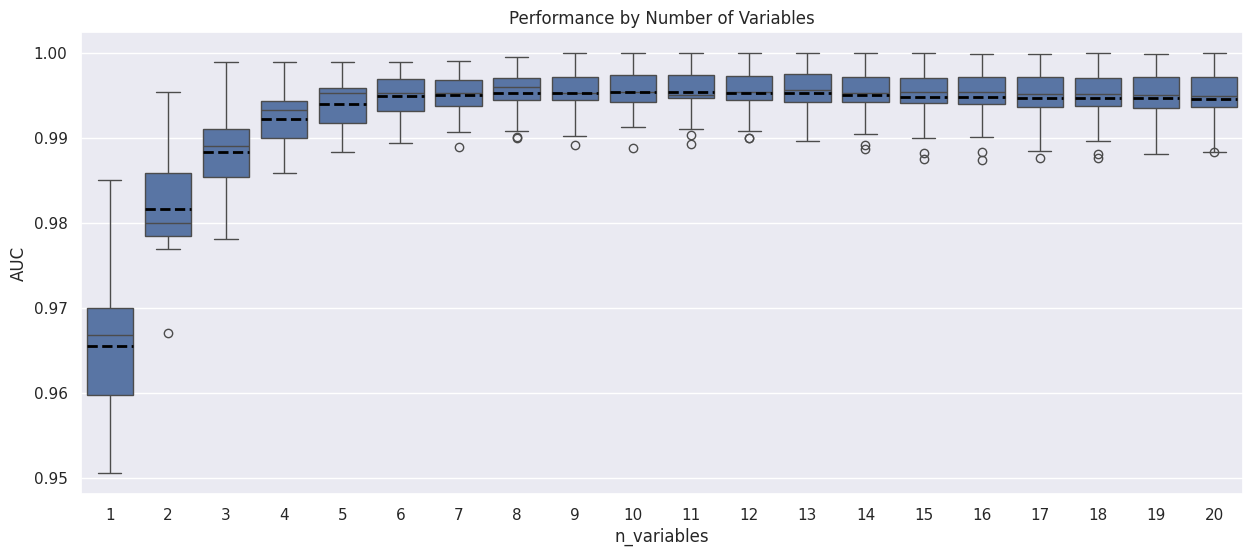

In [83]:
import seaborn as sns


def performance_forward_selection_boxplot(df_metric, metric_name):

    """
    Creates a boxplot showing the distribution of a performance metric 
    across different numbers of selected variables, for multiple bootstrap iterations.

    This visualization helps to analyze how model performance behaves 
    as the number of features increases/decreases, including stability 
    (spread across bootstraps) and potential overfitting/underfitting patterns.

    Parameters
    ----------
    df_metric : pd.DataFrame
        DataFrame where:
        - Index = number of variables (0, 1, 2, ...) 
        - Columns = different bootstrap iterations
        - Values = performance metric (e.g. AUC, F1, RMSE, etc.)
    metric_name : str
        Name of the metric being plotted (used in axis label and title)
    figsize : tuple, optional
        Figure size (width, height), by default (15, 6)
    title : str or None, optional
        Custom title for the plot. If None, a default title is generated.
    xlabel : str, optional
        Label for the x-axis, by default "Number of Variables"
    ylabel : str or None, optional
        Label for the y-axis. If None, uses metric_name capitalized.
    palette : str, optional
        Color palette name for seaborn, by default "viridis"

    Returns
    -------
    None
        Displays the plot (does not return the figure/axis)

    Examples
    --------
    >>> performance_boxplot(df_auc_results, "AUC", figsize=(16, 7), palette="magma")
    >>> performance_boxplot(df_rmse, "RMSE", title="Model RMSE vs Number of Features")
    """
    
    # Garante cópia
    df_aux = df_metric.copy()

    # Índice representa número de variáveis (step)
    df_aux = df_aux.reset_index()
    df_aux.rename(columns={"index": "n_variables"}, inplace=True)

    # Começar contagem em 1
    df_aux["n_variables"] += 1

    # Converte para formato long
    df_long = df_aux.melt(
        id_vars="n_variables",
        var_name="bootstrap",
        value_name=metric_name
    )

    # =============================
    # Plot
    # =============================
    plt.rcParams.update(plt.rcParamsDefault)
    sns.set(rc={'figure.figsize': (15, 6)})
    sns.set_style("darkgrid")

    meanprops = dict(color='black', linewidth=2)

    ax = sns.boxplot(
        data=df_long,
        x="n_variables",
        y=metric_name,
        showmeans=True,
        meanline=True,
        meanprops=meanprops
    )

    ax.set_title("Performance by Number of Variables")

    plt.show()
    
flag_run = 1
if flag_run == 1:
    performance_forward_selection_boxplot(result_bootstrap["auc_roc"], "AUC")

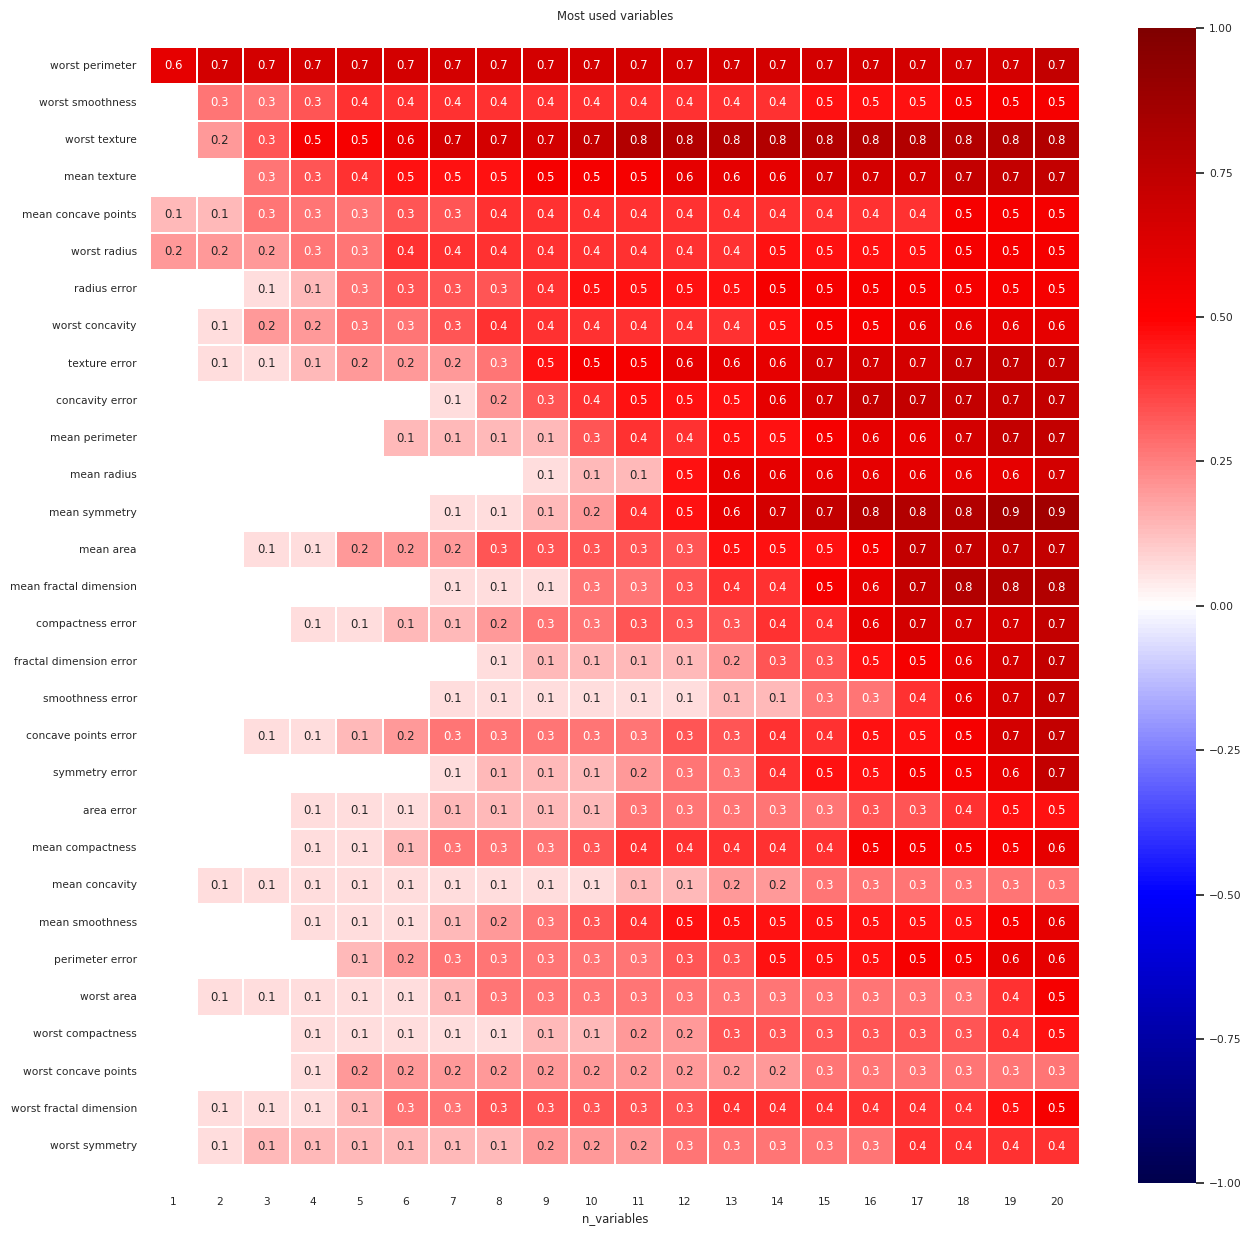

In [85]:
def variable_frequency_forward_selection(df, n_bootstraps, figsize = (15, 15)):
    """
    Creates a heatmap showing the frequency (proportion) with which each variable
    was selected in models with different numbers of variables.
    """

    df_aux = df.copy()

    # Convert the data into counts per variable for each n_variables combination
    df_variables_heatmap = (
        df_aux.iloc[:, :-1]
        .apply(pd.Series.value_counts, axis=1)
        .fillna(0)
    )

    # Normalize by number of bootstraps → convert counts into proportions
    df_variables_heatmap = df_variables_heatmap / n_bootstraps

    # Cumulative frequency (forward selection effect)
    df_variables_heatmap = df_variables_heatmap.cumsum()

    # Remove zeros
    df_variables_heatmap = df_variables_heatmap.replace({0: np.nan})

    # Ensure counting starts at 1
    df_variables_heatmap["n_variables"] = range(1, len(df_variables_heatmap) + 1)

    # Set index
    df_variables_heatmap = df_variables_heatmap.set_index("n_variables")

    # -------------------------------------------------
    # ROW ORDERING ALGORITHM (greedy by column)
    # -------------------------------------------------
    df_order = df_variables_heatmap.T.copy()

    ordered_rows = []
    remaining_rows = list(df_order.index)

    for col in df_order.columns:

        if not remaining_rows:
            break

        # choose row with largest value in this column
        best_row = df_order.loc[remaining_rows, col].idxmax()

        ordered_rows.append(best_row)
        remaining_rows.remove(best_row)

    # append remaining rows if any
    ordered_rows.extend(remaining_rows)

    df_order = df_order.loc[ordered_rows]

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------


    plt.figure(figsize=figsize)

    sns.set(font_scale=0.7)

    with sns.axes_style("white"):
        ax = sns.heatmap(
            df_order,
            linewidths=0.2,
            annot=True,
            fmt=".1f",
            cmap="seismic",
            vmin=-1,
            vmax=1
        )

    plt.title("Most used variables")

    bottom, top = ax.get_ylim()
    ax.set_ylim(bottom + 0.5, top - 0.5)

    plt.show()
    plt.close()

# Exemple:
flag_run = 1
if flag_run == 1:
    variable_frequency_forward_selection(
        result_bootstrap["variables"],
        n_bootstraps=15,
        figsize = (15, 15)
    )

In [86]:
def _compute_forward_selection_order(df_variables_heatmap):
    """
    Internal function to compute the greedy ordering used in the heatmap.
    """

    df_order = df_variables_heatmap.T.copy()

    ordered_rows = []
    remaining_rows = list(df_order.index)

    for col in df_order.columns:

        if not remaining_rows:
            break

        best_row = df_order.loc[remaining_rows, col].idxmax()

        ordered_rows.append(best_row)
        remaining_rows.remove(best_row)

    ordered_rows.extend(remaining_rows)

    return ordered_rows

def top_k_forward_selection_variables_by_frequency_usage(df, n_bootstraps, k=10):
    """
    Return the top-k variables using the same ordering used in the
    variable_frequency_forward_selection heatmap.

    Parameters
    ----------
    df : pd.DataFrame
        result_bootstrap["variables"]

    n_bootstraps : int
        Number of bootstrap iterations.

    k : int, default=10
        Number of variables to return.

    return_df : bool, default=False
        If True, returns a DataFrame with variable ranks.

    Returns
    -------
    list or pd.DataFrame
        List of top-k variables or a DataFrame with ranking.
    """

    df_aux = df.copy()

    df_variables_heatmap = (
        df_aux.iloc[:, :-1]
        .apply(pd.Series.value_counts, axis=1)
        .fillna(0)
    )

    df_variables_heatmap = df_variables_heatmap / n_bootstraps
    df_variables_heatmap = df_variables_heatmap.cumsum()
    df_variables_heatmap = df_variables_heatmap.replace({0: np.nan})

    df_variables_heatmap["n_variables"] = range(1, len(df_variables_heatmap) + 1)
    df_variables_heatmap = df_variables_heatmap.set_index("n_variables")

    ordered_rows = _compute_forward_selection_order(df_variables_heatmap)

    top_k = ordered_rows[:k]

    return top_k

# Example usage
flag_run = 1
if flag_run == 1:
    top_vars = top_k_forward_selection_variables_by_frequency_usage(
        result_bootstrap["variables"],
        n_bootstraps=15,
        k=8
    )
    
    print(top_vars)

['worst perimeter', 'worst smoothness', 'worst texture', 'mean texture', 'mean concave points', 'worst radius', 'radius error', 'worst concavity']


In [87]:
import numpy as np
import pandas as pd


def top_k_variables_by_forward_selection_boxplot(result_bootstrap, k, metric):
    """
    Returns the k variables that produced the best performance
    for a given metric.

    Parameters
    ----------
    result_bootstrap : dict
        Dictionary containing:
        - "variables"
        - performance metrics (e.g. "auc_roc", "accuracy")

    k : int
        Number of variables in the model

    metric : str
        Performance metric key inside result_bootstrap

    Returns
    -------
    variables : list
        List with the k variables

    performance : float
        Best performance obtained
    """

    df_vars = result_bootstrap["variables"]
    df_metric = result_bootstrap[metric]

    row = k - 1

    # performance row
    perf_row = df_metric.loc[row]

    # maximum performance
    performance = perf_row.max()

    # bootstrap column where max occurs
    best_col = perf_row.idxmax()

    # corresponding variables
    variables = df_vars.loc[:row, best_col].tolist()

    return variables, performance

# Example usage
flag_run = 1
if flag_run == 1:
    vars_best, perf = top_k_variables_by_forward_selection_boxplot(
        result_bootstrap,
        k=2,
        metric="auc_roc"
    )
    
    print(vars_best)
    print()
    print(perf)

['worst perimeter', 'worst fractal dimension']

0.9954626159005721


In [147]:
def bootstrap_model_variable_comparison_paired_lgbm(
    df_train,
    base_variables,
    target_col,
    df_val=None,
    start_month_col=None,
    variables_to_remove=None,
    variables_to_add=None,
    n_bootstrap=100,
    metric="auc",
    hyperparameters=None
):
    """
    Paired bootstrap comparison between two LightGBM classification models:
    
        1) Baseline (base_variables)
        2) Modified (remove/add variables)

    Uses stratified bootstrap.
    Returns formal statistical inference.
    """

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from tqdm import tqdm
    from lightgbm import LGBMClassifier
    from sklearn.metrics import (
        roc_auc_score,
        log_loss,
        accuracy_score,
        f1_score
    )

    if hyperparameters is None:
        hyperparameters = {}

    # -----------------------------------
    # Build modified variable list
    # -----------------------------------
    modified_variables = base_variables.copy()

    if variables_to_remove:
        modified_variables = [v for v in modified_variables if v not in variables_to_remove]

    if variables_to_add:
        modified_variables = list(set(modified_variables + variables_to_add))

    better_is_lower = metric in ["logloss"]

    # -----------------------------------
    # Data split
    # -----------------------------------
    if df_val is None:
    
        if start_month_col is not None:
            # Temporal split (time-ordered)
            df_train = df_train.sort_values(start_month_col)
            split_index = int(len(df_train) * 0.8)
    
            df_val = df_train.iloc[split_index:].copy()
            df_train = df_train.iloc[:split_index].copy()
    
        else:
            # Random stratified split (i.i.d. assumption)
            df_train, df_val = train_test_split(
                df_train,
                test_size=0.2,
                stratify=df_train[target_col],
                random_state=42
            )

    base_scores = []
    mod_scores = []
    differences = []

    # -----------------------------------
    # Stratified bootstrap
    # -----------------------------------
    for b in tqdm(range(n_bootstrap)):

        # ======================================================
        # BOOTSTRAP
        # ======================================================
        n_samples = len(df_train)
        rng = np.random.default_rng(b)
        bootstrap_idx = rng.integers(0, n_samples, n_samples)

        oob_mask = np.ones(n_samples, dtype=bool)
        oob_mask[bootstrap_idx] = False

        if oob_mask.sum() == 0:
            continue  # caso raríssimo

        df_boot = df_train.iloc[bootstrap_idx]

        if df_boot[target_col].nunique() < 2:
            continue

        # ---------------------------
        # Baseline model
        # ---------------------------
        model_base = LGBMClassifier(**hyperparameters)
        model_base.fit(
            df_boot[base_variables],
            df_boot[target_col]
        )

        preds_base = model_base.predict_proba(df_val[base_variables])[:, 1]

        # ---------------------------
        # Modified model
        # ---------------------------
        model_mod = LGBMClassifier(**hyperparameters)
        model_mod.fit(
            df_boot[modified_variables],
            df_boot[target_col]
        )

        preds_mod = model_mod.predict_proba(df_val[modified_variables])[:, 1]

        # ---------------------------
        # Metric computation
        # ---------------------------
        y_val = df_val[target_col]

        if metric == "auc":
            base_score = roc_auc_score(y_val, preds_base)
            mod_score = roc_auc_score(y_val, preds_mod)

        elif metric == "logloss":
            base_score = log_loss(y_val, preds_base)
            mod_score = log_loss(y_val, preds_mod)

        elif metric == "accuracy":
            base_score = accuracy_score(y_val, preds_base > 0.5)
            mod_score = accuracy_score(y_val, preds_mod > 0.5)

        elif metric == "f1":
            base_score = f1_score(y_val, preds_base > 0.5)
            mod_score = f1_score(y_val, preds_mod > 0.5)

        else:
            raise ValueError("Unsupported metric")

        base_scores.append(base_score)
        mod_scores.append(mod_score)
        differences.append(mod_score - base_score)

    base_scores = np.array(base_scores)
    mod_scores = np.array(mod_scores)
    differences = np.array(differences)

    # ======================================================
    # Plot 1 — Performance Distribution
    # ======================================================

    removed_str = ", ".join(variables_to_remove) if variables_to_remove else "None"
    added_str = ", ".join(variables_to_add) if variables_to_add else "None"

    base_label = f"Baseline\nVars: {', '.join(base_variables)}"
    mod_label = f"Modified\nRemoved: {removed_str}\nAdded: {added_str}"

    plt.figure(figsize=(8, 6))
    box = plt.boxplot([base_scores, mod_scores], patch_artist=True)

    colors = ["#4C72B0", "#55A868"]
    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    for median in box["medians"]:
        median.set_color("black")
        median.set_linewidth(2)

    plt.xticks([1, 2], [base_label, mod_label])
    plt.ylabel(metric.upper())
    plt.title("Validation Performance (Bootstrap Distribution)")
    plt.grid(False)
    plt.gcf().set_facecolor("white")
    plt.gca().set_facecolor("white")
    plt.tight_layout()
    plt.show()

    # ======================================================
    # Plot 2 — Paired Difference
    # ======================================================

    if better_is_lower:
        direction_text = "Negative values favor Modified (lower is better)"
    else:
        direction_text = "Positive values favor Modified (higher is better)"

    plt.figure(figsize=(7, 5))
    box = plt.boxplot(differences, patch_artist=True)
    box["boxes"][0].set_facecolor("#C44E52")
    box["boxes"][0].set_alpha(0.6)
    box["medians"][0].set_color("black")

    plt.axhline(0, linestyle="--")
    plt.xticks([1], ["Modified − Baseline"])
    plt.ylabel(metric.upper())
    plt.title(
        "Paired Validation Difference (Modified − Baseline)\n"
        f"{direction_text}"
    )
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    # ======================================================
    # Statistical Inference
    # ======================================================

    mean_diff = differences.mean()
    ci_low, ci_high = np.percentile(differences, [2.5, 97.5])

    if better_is_lower:
        prob_better = np.mean(differences < 0)
    else:
        prob_better = np.mean(differences > 0)

    p_value = 2 * min(
        np.mean(differences > 0),
        np.mean(differences < 0)
    )

    return {
        "baseline_mean": base_scores.mean(),
        "modified_mean": mod_scores.mean(),
        "mean_difference": mean_diff,
        "ci_2_5": ci_low,
        "ci_97_5": ci_high,
        "probability_modified_better": prob_better,
        "two_sided_p_value": p_value,
        "n_effective_bootstrap": len(differences)
    }

100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:06<00:00, 14.78it/s]


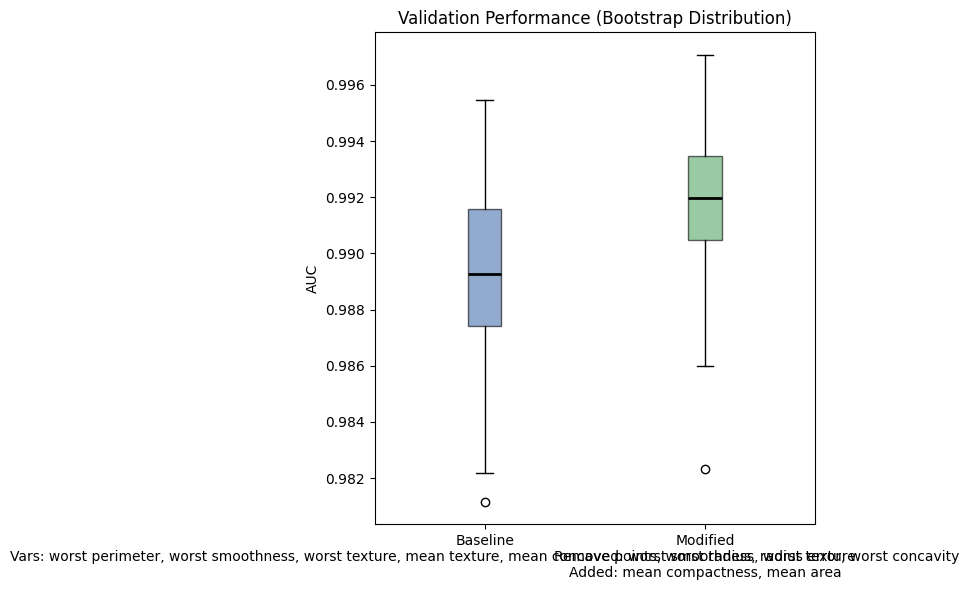

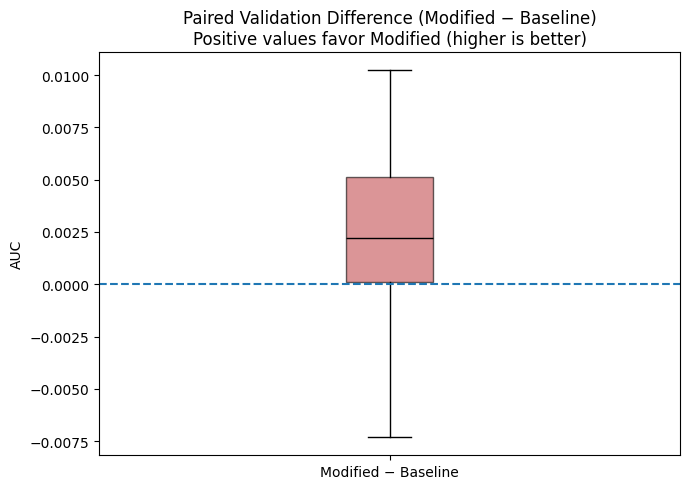

{'baseline_mean': np.float64(0.98935601635514),
 'modified_mean': np.float64(0.9917158294392524),
 'mean_difference': np.float64(0.00235981308411215),
 'ci_2_5': np.float64(-0.0036726051401869547),
 'ci_97_5': np.float64(0.008400262850467324),
 'probability_modified_better': np.float64(0.75),
 'two_sided_p_value': np.float64(0.48),
 'n_effective_bootstrap': 100}

In [148]:
bootstrap_model_variable_comparison_paired_lgbm(
    df_train,
    base_variables=['worst perimeter', 'worst smoothness', 'worst texture', 'mean texture', 'mean concave points', 'worst radius', 'radius error', 'worst concavity'],
    target_col='target',
    df_val=df_val,
    start_month_col=None,
    variables_to_remove=['worst smoothness', 'worst texture'],
    variables_to_add=['mean compactness', 'mean area'],
    n_bootstrap=100,
    metric="auc",
    hyperparameters=None
)

In [138]:
df_train

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
469,11.620,18.18,76.38,408.8,0.11750,0.14830,0.10200,0.05564,0.1957,0.07255,...,25.40,88.14,528.1,0.17800,0.28780,0.31860,0.14160,0.2660,0.09270,1
561,11.200,29.37,70.67,386.0,0.07449,0.03558,0.00000,0.00000,0.1060,0.05502,...,38.30,75.19,439.6,0.09267,0.05494,0.00000,0.00000,0.1566,0.05905,1
443,10.570,18.32,66.82,340.9,0.08142,0.04462,0.01993,0.01111,0.2372,0.05768,...,23.31,69.35,366.3,0.09794,0.06542,0.03986,0.02222,0.2699,0.06736,1
362,12.760,18.84,81.87,496.6,0.09676,0.07952,0.02688,0.01781,0.1759,0.06183,...,25.99,87.82,579.7,0.12980,0.18390,0.12550,0.08312,0.2744,0.07238,1
271,11.290,13.04,72.23,388.0,0.09834,0.07608,0.03265,0.02755,0.1769,0.06270,...,16.18,78.27,457.5,0.13580,0.15070,0.12750,0.08750,0.2733,0.08022,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,15.280,22.41,98.92,710.6,0.09057,0.10520,0.05375,0.03263,0.1727,0.06317,...,28.03,113.80,973.1,0.13010,0.32990,0.36300,0.12260,0.3175,0.09772,0
300,19.530,18.90,129.50,1217.0,0.11500,0.16420,0.21970,0.10620,0.1792,0.06552,...,26.24,171.10,2053.0,0.14950,0.41160,0.61210,0.19800,0.2968,0.09929,0
220,13.650,13.16,87.88,568.9,0.09646,0.08711,0.03888,0.02563,0.1360,0.06344,...,16.35,99.71,706.2,0.13110,0.24740,0.17590,0.08056,0.2380,0.08718,1
230,17.050,19.08,113.40,895.0,0.11410,0.15720,0.19100,0.10900,0.2131,0.06325,...,24.89,133.50,1189.0,0.17030,0.39340,0.50180,0.25430,0.3109,0.09061,0


## Survival analysis

In [ ]:
# !pip install lifelines scikit-survival

In [88]:
import numpy as np
import pandas as pd
from tqdm import tqdm

from lifelines import WeibullAFTFitter, LogNormalAFTFitter, CoxPHFitter
from lifelines.utils import concordance_index

from sksurv.metrics import (
    concordance_index_ipcw,
    integrated_brier_score,
    brier_score
)
from sksurv.util import Surv


# ==========================================================
# MODEL FACTORY
# ==========================================================
def build_lifelines_model(model_type, hyperparameters):

    if model_type == "aft_weibull":
        return WeibullAFTFitter(**hyperparameters)

    elif model_type == "aft_lognormal":
        return LogNormalAFTFitter(**hyperparameters)

    elif model_type == "cox_breslow":
        return CoxPHFitter(baseline_estimation_method="breslow", **hyperparameters)

    elif model_type == "cox_spline":
        return CoxPHFitter(baseline_estimation_method="spline", **hyperparameters)

    else:
        raise ValueError("Unsupported model_type")

    
# ==========================================================
# BOOTSTRAP
# ==========================================================
def discrete_duration_bootstrap(
    df,
    duration_col,
    event_col,
    rng
):
    """
    Bootstrap preserving:
        - exact discrete duration distribution
        - exact event proportion within each duration
    """

    df = df.copy()

    # Stratify by (duration, event)
    grouped = df.groupby([duration_col, event_col], group_keys=False)

    boot_samples = []

    for (duration, event), group in grouped:
        n = len(group)

        # Sample with replacement within this exact stratum
        idx = rng.integers(0, n, n)
        boot_samples.append(group.iloc[idx])

    df_boot = pd.concat(boot_samples).reset_index(drop=True)

    return df_boot

# ==========================================================
# METRICS
# ==========================================================
def compute_survival_metrics(
    model,
    df_train,
    df_val,
    duration_col,
    event_col,
    n_times=100
):
    """
    Compute survival metrics for lifelines models.

    Returns:
        dict with:
            - Harrell C-index: ranking discrimination
            - c_index_ipcw: censoring-adjusted concordance
            - Integrated Brier Score: overall calibration + discrimination
            - Mean Time-dependent Brier Score
    """

    # =====================================================
    # Structured arrays (required by sksurv)
    # =====================================================

    y_train_struct = Surv.from_dataframe(event_col, duration_col, df_train)
    y_val_struct = Surv.from_dataframe(event_col, duration_col, df_val)

    # =====================================================
    # Risk scores (for C-index)
    # =====================================================

    if hasattr(model, "predict_partial_hazard"):
        # Cox models
        risk_scores = model.predict_partial_hazard(df_val).values.ravel()
    else:
        # AFT models → higher survival time = lower risk
        risk_scores = -model.predict_expectation(df_val).values.ravel()

    # Standard C-index
    c_index = concordance_index(
        df_val[duration_col],
        -risk_scores,  # lifelines expects higher survival = better
        df_val[event_col]
    )

    # IPCW C-index
    c_ipcw = concordance_index_ipcw(
        y_train_struct,
        y_val_struct,
        risk_scores
    )[0]

    # =====================================================
    # Time grid (STRICTLY inside validation follow-up)
    # =====================================================

    t_min = df_val[duration_col].min()
    t_max = df_val[duration_col].max()

    # Must satisfy: t < max(T_val)
    times_eval = np.linspace(t_min, t_max - 1e-8, n_times)

    # =====================================================
    # Survival probability matrix
    # =====================================================

    surv_df = model.predict_survival_function(df_val)
    
    # Interpolate survival curves at evaluation times
    surv_interp = (
        surv_df
        .reindex(surv_df.index.union(times_eval))
        .interpolate(method="index")
        .loc[times_eval]
    )

    # shape → (n_samples, n_times)
    surv_preds = surv_interp.T.values
    if np.isnan(surv_preds).any():
        return {
            "c_index": np.nan,
            "c_index_ipcw": np.nan,
            "ibs": np.inf,
            "mean_brier": np.inf
        }
    
    # =====================================================
    # Brier score + IBS
    # =====================================================

    _, bs_values = brier_score(
        y_train_struct,
        y_val_struct,
        surv_preds,
        times_eval
    )

    ibs = integrated_brier_score(
        y_train_struct,
        y_val_struct,
        surv_preds,
        times_eval
    )

    return {
        "c_index": c_index,
        "c_index_ipcw": c_ipcw,
        "ibs": ibs,
        "mean_brier": np.mean(bs_values)
    }
    
    
# ==========================================================
# MAIN FUNCTION
# ==========================================================
def bootstrap_survival_forward_selection(
    df_train,
    duration_col,
    event_col,
    start_month_col,
    model_type,
    n_bootstrap,
    n_max_variables,
    metric_to_optimize,
    hyperparameters,
    df_val=None
):
    """
    Bootstrap forward selection for cohort survival data.

    If df_val is None:
        - Uses last 20% most recent start_month as validation.

    Bootstrap is applied ONLY to training set.
    """

    # ------------------------------------------------------
    # Temporal split if df_val not provided
    # ------------------------------------------------------
    if df_val is None:

        df_train = df_train.sort_values(start_month_col)

        split_index = int(len(df_train) * 0.8)

        df_val = df_train.iloc[split_index:].copy()
        df_train = df_train.iloc[:split_index].copy()

    # ------------------------------------------------------
    # Feature columns
    # ------------------------------------------------------
    feature_cols = [
        col for col in df_train.columns
        if col not in [duration_col, event_col, start_month_col]
    ]

    results_metrics = {
        "c_index": [],
        "c_index_ipcw": [],
        "ibs": [],
        "mean_brier": []
    }

    results_variables = []

    n_train = len(df_train)

    # ------------------------------------------------------
    # Bootstrap Loop
    # ------------------------------------------------------
    for b in tqdm(range(n_bootstrap)):

        rng = np.random.default_rng(b)

        # IID bootstrap on training users
        df_train_boot = discrete_duration_bootstrap(
            df_train,
            duration_col=duration_col,
            event_col=event_col,
            rng=rng
        )
        if df_train_boot[event_col].sum() < 10:
            continue  # skip bootstrap draw
        
        selected_features = []
        remaining_features = feature_cols.copy()
        metrics_history = []

 
        # --------------------------------------------------
        # Forward Selection
        # --------------------------------------------------
        for _ in range(min(n_max_variables, len(remaining_features))):

            best_feature = None
            best_score = -np.inf

            for feature in remaining_features:

                trial_features = selected_features + [feature]

                model = build_lifelines_model(
                    model_type,
                    hyperparameters
                )

                model.fit(
                    df_train_boot[trial_features + [duration_col, event_col]],
                    duration_col=duration_col,
                    event_col=event_col
                )

                metrics = compute_survival_metrics(
                    model,
                    df_train_boot[trial_features + [duration_col, event_col]],
                    df_val[trial_features + [duration_col, event_col]],
                    duration_col,
                    event_col,
                )

                score = metrics[metric_to_optimize]

                # Reverse sign for minimization metrics
                if metric_to_optimize in ["ibs", "mean_brier"]:
                    score = -score

                if score > best_score:
                    best_score = score
                    best_feature = feature
                    best_metrics = metrics

            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            metrics_history.append(best_metrics)

        results_variables.append(selected_features)

        for metric_name in results_metrics:
            results_metrics[metric_name].append(
                [step[metric_name] for step in metrics_history]
            )

    return {
        "variables": pd.DataFrame(results_variables).T,
        **{
            k: pd.DataFrame(v).T
            for k, v in results_metrics.items()
        }
    }

In [93]:
# Get data
from lifelines.datasets import load_rossi

df = load_rossi()
df = df.rename(columns={
    "week": "duration",
    "arrest": "event"
})
# Simulate entry month
start_months = pd.date_range("2020-01-01", periods=24, freq="MS")
rng = np.random.default_rng(1)
n = len(df)
df["start_year_month"] = rng.choice(start_months, size=n)
df = df.sort_values("start_year_month").reset_index(drop=True)

df.head()

,duration,event,fin,age,race,wexp,mar,paro,prio,start_year_month
0,52,0,1,38,1,1,0,1,1,2020-01-01
1,52,0,1,22,1,0,0,0,2,2020-01-01
2,52,0,1,28,1,1,0,0,0,2020-01-01
3,52,0,0,25,1,1,1,1,2,2020-01-01
4,52,0,0,23,1,1,0,0,0,2020-01-01


In [94]:
hyperparameters = {
    "penalizer": 0.01
}

results_bootstrap_survival_forward_selection = bootstrap_survival_forward_selection(
    df_train=df,
    duration_col="duration",
    event_col="event",
    start_month_col="start_year_month",
    model_type="aft_weibull",  #cox_breslow, cox_spline, aft_lognormal, aft_weibull
    n_bootstrap=30,
    n_max_variables=7,
    metric_to_optimize="ibs",
    hyperparameters=hyperparameters,
    df_val=None  # triggers temporal split
)

100%|███████████████████████████████████████████████████████████████████████████████████| 30/30 [02:26<00:00,  4.89s/it]


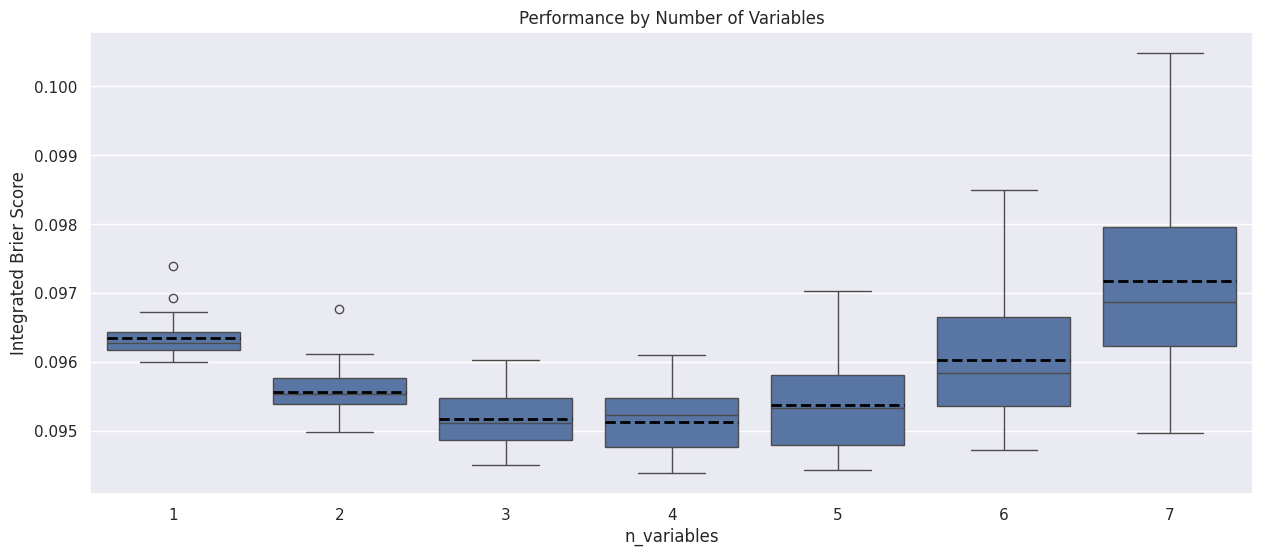

In [95]:
performance_forward_selection_boxplot(results_bootstrap_survival_forward_selection["ibs"], "Integrated Brier Score")

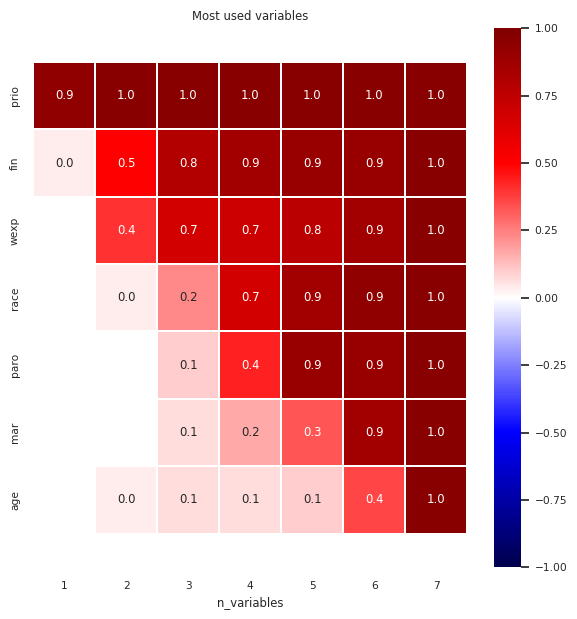

In [101]:
variable_frequency_forward_selection(
    results_bootstrap_survival_forward_selection["variables"],
    n_bootstraps=30,
    figsize = (7, 7)
)

In [102]:
top_vars = top_k_forward_selection_variables_by_frequency_usage(
        results_bootstrap_survival_forward_selection["variables"],
        n_bootstraps=30,
        k=3
    )
top_vars

['prio', 'fin', 'wexp']

In [99]:
vars_best, perf = top_k_variables_by_forward_selection_boxplot(
    results_bootstrap_survival_forward_selection,
    k=3,
    metric="ibs"
)

print(vars_best)
print()
print(perf)

['prio', 'fin', 'paro']

0.0960233770018704


In [131]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


def bootstrap_model_variable_comparison_paired(
    df_train,
    model_type,
    base_variables,
    df_val=None,
    duration_col='duration',
    event_col='event',
    start_month_col='start_month',
    variables_to_remove=None,
    variables_to_add=None,
    n_bootstrap=50,
    metric="ibs",
    hyperparameters=None
):

    """
    Performs a paired bootstrap comparison between two survival models:
    
        1) Baseline model using `base_variables`
        2) Modified model obtained by removing and/or adding variables
    
    The function:
    - Uses temporal split (80/20) if `df_val` is not provided.
    - Applies a stratified discrete bootstrap on the training set
      preserving the duration distribution.
    - Fits both models on each bootstrap sample.
    - Evaluates validation performance using the selected survival metric
      (e.g., IBS, mean_brier, c_index, c_index_ipcw).
    - Produces two plots:
        • Validation performance distributions (baseline vs modified)
        • Paired bootstrap difference distribution (Modified − Baseline)
          with interpretation of improvement direction.
    - Returns statistical inference including:
        • Mean validation performance (baseline and modified)
        • Mean paired difference
        • 95% bootstrap confidence interval
        • Probability that modified model outperforms baseline
        • Effective number of bootstrap samples used
    
    Parameters
    ----------
    df_train : pd.DataFrame
        Training dataset.
    
    model_type : str
        Survival model identifier
        ("cox_breslow", "cox_spline", "aft_lognormal", "aft_weibull").
    
    base_variables : list[str]
        Variables used in the baseline model.
    
    df_val : pd.DataFrame or None
        Validation dataset. If None, a temporal 80/20 split is applied.
    
    duration_col : str
        Column containing survival times.
    
    event_col : str
        Column containing event indicator (1=event, 0=censored).
    
    start_month_col : str
        Column used for temporal ordering when splitting.
    
    variables_to_remove : list[str] or None
        Variables removed from baseline in modified model.
    
    variables_to_add : list[str] or None
        Variables added to baseline in modified model.
    
    n_bootstrap : int
        Number of bootstrap iterations.
    
    metric : str
        Performance metric to evaluate.
    
    hyperparameters : dict
        Model hyperparameters passed to builder.
    
    Returns
    -------
    dict
        Statistical summary of paired bootstrap comparison.
    """
    
    if hyperparameters is None:
        hyperparameters = {}

    # -------------------------------
    # Build modified variable list
    # -------------------------------
    modified_variables = base_variables.copy()

    if variables_to_remove is not None:
        modified_variables = [
            v for v in modified_variables if v not in variables_to_remove
        ]

    if variables_to_add is not None:
        modified_variables = list(set(modified_variables + variables_to_add))

    better_is_lower = metric in ["ibs", "mean_brier"]

    # ------------------------------------------------------
    # Temporal split if df_val not provided
    # ------------------------------------------------------
    if df_val is None:

        df_train = df_train.sort_values(start_month_col)
        split_index = int(len(df_train) * 0.8)

        df_val = df_train.iloc[split_index:].copy()
        df_train = df_train.iloc[:split_index].copy()

    # Storage
    base_val_scores = []
    mod_val_scores = []
    differences = []

    # ======================================================
    # Bootstrap loop
    # ======================================================
    for b in tqdm(range(n_bootstrap)):

        rng = np.random.default_rng(b)

        df_train_boot = discrete_duration_bootstrap(
            df_train,
            duration_col,
            event_col,
            rng
        )

        # Skip degenerate bootstrap draws
        if df_train_boot[event_col].sum() < 5:
            continue

        # ==========================
        # BASELINE MODEL
        # ==========================
        model_base = build_lifelines_model(model_type, hyperparameters)

        model_base.fit(
            df_train_boot[base_variables + [duration_col, event_col]],
            duration_col=duration_col,
            event_col=event_col
        )

        metrics_base_val = compute_survival_metrics(
            model_base,
            df_train_boot[base_variables + [duration_col, event_col]],
            df_val[base_variables + [duration_col, event_col]],
            duration_col,
            event_col
        )

        base_score = metrics_base_val[metric]
        base_val_scores.append(base_score)

        # ==========================
        # MODIFIED MODEL
        # ==========================
        model_mod = build_lifelines_model(model_type, hyperparameters)

        model_mod.fit(
            df_train_boot[modified_variables + [duration_col, event_col]],
            duration_col=duration_col,
            event_col=event_col
        )

        metrics_mod_val = compute_survival_metrics(
            model_mod,
            df_train_boot[modified_variables + [duration_col, event_col]],
            df_val[modified_variables + [duration_col, event_col]],
            duration_col,
            event_col
        )

        mod_score = metrics_mod_val[metric]
        mod_val_scores.append(mod_score)

        differences.append(mod_score - base_score)

    # Convert to arrays
    base_val_scores = np.array(base_val_scores)
    mod_val_scores = np.array(mod_val_scores)
    differences = np.array(differences)

    # ======================================================
    # Label construction
    # ======================================================
    
    removed_str = ", ".join(variables_to_remove) if variables_to_remove else "None"
    added_str = ", ".join(variables_to_add) if variables_to_add else "None"
    
    base_label = f"Baseline\nVars: {', '.join(base_variables)}"
    mod_label = (
        f"Modified\n"
        f"Removed: {removed_str}\n"
        f"Added: {added_str}"
    )
    
    # ======================================================
    # PLOT 1: Validation Performance Comparison
    # ======================================================
    
    plt.figure(figsize=(8, 6))
    
    box = plt.boxplot(
        [base_val_scores, mod_val_scores],
        patch_artist=True,
        widths=0.6
    )
    
    # Color styling
    colors = ["#4C72B0", "#55A868"]
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    # Emphasize medians
    for median in box['medians']:
        median.set_color("black")
        median.set_linewidth(2)
    
    # Jittered points
    for i, scores in enumerate([base_val_scores, mod_val_scores], start=1):
        x = np.random.normal(i, 0.04, size=len(scores))
        plt.scatter(x, scores, alpha=0.4)
    
    plt.style.use("default")  # ensures white background
    plt.xticks([1, 2], [base_label, mod_label])
    plt.ylabel(metric.upper())
    plt.title("Validation Performance (Bootstrap Distribution)")
    
    plt.grid(False)  # removes grid completely
    
    plt.gcf().set_facecolor("white")   # figure background
    plt.gca().set_facecolor("white")   # axes background
    
    plt.tight_layout()
    plt.show()
    
    # ======================================================
    # PLOT 2: Paired Difference (Validation)
    # ======================================================
    # Determine direction
    if better_is_lower:
        direction_text = "Negative values favor Modified (lower is better)"
    else:
        direction_text = "Positive values favor Modified (higher is better)"
    plt.figure(figsize=(7, 5))
    
    box = plt.boxplot(
        differences,
        patch_artist=True,
        widths=0.5
    )
    
    box['boxes'][0].set_facecolor("#C44E52")
    box['boxes'][0].set_alpha(0.6)
    
    box['medians'][0].set_color("black")
    box['medians'][0].set_linewidth(2)
    
    # Jittered differences
    x = np.random.normal(1, 0.04, size=len(differences))
    plt.scatter(x, differences, alpha=0.4)
    
    plt.axhline(0, linestyle="--")
    plt.xticks([1], ["Modified − Baseline"])
    plt.ylabel(metric.upper())
    plt.title(
        "Paired Validation Difference (Modified − Baseline)\n"
        f"{direction_text}"
    )
    plt.grid(False)  # removes grid completely
    plt.tight_layout()
    plt.show()

    # ======================================================
    # Inference
    # ======================================================
    mean_diff = np.mean(differences)
    ci_low, ci_high = np.percentile(differences, [2.5, 97.5])

    if better_is_lower:
        prob_better = np.mean(differences < 0)
    else:
        prob_better = np.mean(differences > 0)

    return {
        "baseline_val_mean": np.mean(base_val_scores),
        "modified_val_mean": np.mean(mod_val_scores),
        "mean_difference_val": mean_diff,
        "ci_2_5": ci_low,
        "ci_97_5": ci_high,
        "probability_modified_better": prob_better,
        "n_effective_bootstrap": len(differences)
    }

100%|███████████████████████████████████████████████████████████████████████████████████| 50/50 [00:18<00:00,  2.64it/s]


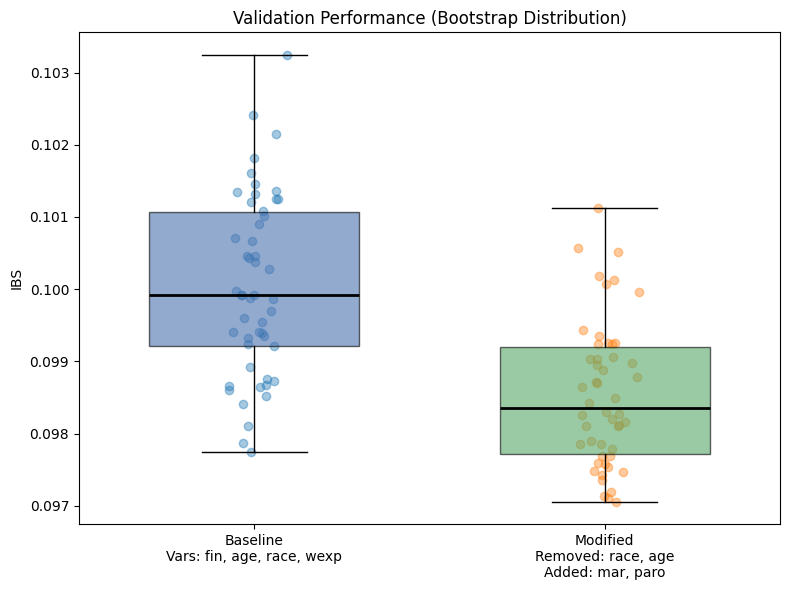

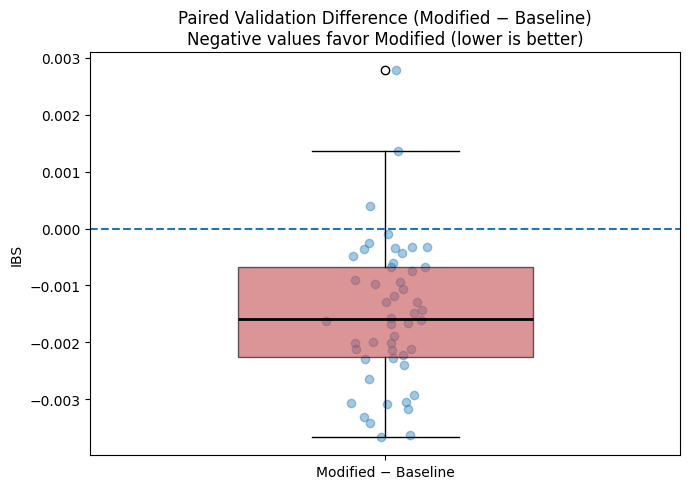

{'baseline_val_mean': np.float64(0.10004109000536164),
 'modified_val_mean': np.float64(0.09854462359496004),
 'mean_difference_val': np.float64(-0.0014964664104016043),
 'ci_2_5': np.float64(-0.0035728089208609524),
 'ci_97_5': np.float64(0.0011438931555702192),
 'probability_modified_better': np.float64(0.94),
 'n_effective_bootstrap': 50}

In [132]:
hyperparameters = {
    "penalizer": 0.01
}
bootstrap_model_variable_comparison_paired(
    df_train = df,
    df_val = None,
    duration_col = 'duration',
    event_col = 'event',
    start_month_col = 'start_year_month',
    model_type="aft_weibull",  #cox_breslow, cox_spline, aft_lognormal, aft_weibull,
    base_variables=['fin', 'age', 'race', 'wexp'],
    variables_to_remove=['race', 'age'],
    variables_to_add=['mar', 'paro'],
    n_bootstrap=50,
    metric="ibs",
    hyperparameters=hyperparameters
)

In [135]:
def survival_bootstrap_model_comparison(
    df_train,
    models_dict,
    feature_cols,
    df_val=None,
    duration_col="duration",
    event_col="event",
    start_month_col="start_month",
    n_bootstrap=50
):
    """
    Bootstrap comparison of multiple lifelines survival models.

    Parameters
    ----------
    df_train : pd.DataFrame
    models_dict : dict
        {"ModelName": model_instance}
    df_val : pd.DataFrame or None
        If None → temporal 80/20 split.
    duration_col : str
    event_col : str
    start_month_col : str
    n_bootstrap : int

    Returns
    -------
    dict with bootstrap distributions and ranking summary
    """

    # --------------------------------------------------
    # Temporal split
    # --------------------------------------------------
    if df_val is None:
        df_train = df_train.sort_values(start_month_col)
        split_index = int(len(df_train) * 0.8)
        df_val = df_train.iloc[split_index:].copy()
        df_train = df_train.iloc[:split_index].copy()

    model_names = list(models_dict.keys())

    ibs_scores = {name: [] for name in model_names}
    cindex_scores = {name: [] for name in model_names}

    # --------------------------------------------------
    # Bootstrap loop
    # --------------------------------------------------
    for b in tqdm(range(n_bootstrap)):

        rng = np.random.default_rng(b)

        df_train_boot = discrete_duration_bootstrap(
            df_train,
            duration_col,
            event_col,
            rng
        )

        if df_train_boot[event_col].sum() < 5:
            continue

        for name, model in models_dict.items():

            model_instance = model.__class__(**model._kwargs) \
                if hasattr(model, "_kwargs") else model.__class__()

            model_instance.fit(
                df_train_boot[feature_cols + [duration_col, event_col]],
                duration_col=duration_col,
                event_col=event_col
            )

            metrics = compute_survival_metrics(
                model_instance,
                df_train_boot,
                df_val,
                duration_col,
                event_col
            )

            ibs_scores[name].append(metrics["ibs"])
            cindex_scores[name].append(metrics["c_index_ipcw"])

    # Convert to arrays
    for name in model_names:
        ibs_scores[name] = np.array(ibs_scores[name])
        cindex_scores[name] = np.array(cindex_scores[name])

    # ======================================================
    # PLOT 1 — IBS
    # ======================================================

    plt.figure(figsize=(9, 6))

    data_ibs = [ibs_scores[name] for name in model_names]

    box = plt.boxplot(data_ibs, patch_artist=True, widths=0.6)

    for patch in box["boxes"]:
        patch.set_alpha(0.6)

    for median in box["medians"]:
        median.set_color("black")
        median.set_linewidth(2)

    plt.xticks(range(1, len(model_names) + 1), model_names)
    plt.ylabel("IBS")
    plt.title("Integrated Brier Score (Lower is Better)")
    plt.grid(False)
    plt.gcf().set_facecolor("white")
    plt.gca().set_facecolor("white")
    plt.tight_layout()
    plt.show()

    # ======================================================
    # PLOT 2 — IPCW C-index
    # ======================================================

    plt.figure(figsize=(9, 6))

    data_c = [cindex_scores[name] for name in model_names]

    box = plt.boxplot(data_c, patch_artist=True, widths=0.6)

    for patch in box["boxes"]:
        patch.set_alpha(0.6)

    for median in box["medians"]:
        median.set_color("black")
        median.set_linewidth(2)

    plt.xticks(range(1, len(model_names) + 1), model_names)
    plt.ylabel("C-index IPCW")
    plt.title("IPCW Concordance Index (Higher is Better)")
    plt.grid(False)
    plt.gcf().set_facecolor("white")
    plt.gca().set_facecolor("white")
    plt.tight_layout()
    plt.show()

    # ======================================================
    # Ranking summary
    # ======================================================

    summary = []

    for name in model_names:
        summary.append({
            "Model": name,
            "IBS_mean": ibs_scores[name].mean(),
            "IBS_median": np.median(ibs_scores[name]),
            "Cindex_mean": cindex_scores[name].mean(),
            "Cindex_median": np.median(cindex_scores[name])
        })

    summary_df = pd.DataFrame(summary)

    # Probability of being best
    ibs_matrix = np.vstack([ibs_scores[n] for n in model_names]).T
    c_matrix = np.vstack([cindex_scores[n] for n in model_names]).T

    best_ibs = np.argmin(ibs_matrix, axis=1)
    best_c = np.argmax(c_matrix, axis=1)

    prob_best_ibs = {
        model_names[i]: np.mean(best_ibs == i)
        for i in range(len(model_names))
    }

    prob_best_c = {
        model_names[i]: np.mean(best_c == i)
        for i in range(len(model_names))
    }

    print("\n===== Bootstrap Ranking Summary =====")
    print(summary_df.sort_values("IBS_mean"))

    print("\nProbability of being best (IBS):")
    print(prob_best_ibs)

    print("\nProbability of being best (C-index IPCW):")
    print(prob_best_c)

    return {
        "ibs_scores": ibs_scores,
        "cindex_scores": cindex_scores,
        "summary": summary_df,
        "prob_best_ibs": prob_best_ibs,
        "prob_best_c": prob_best_c
    }

100%|███████████████████████████████████████████████████████████████████████████████████| 50/50 [00:24<00:00,  2.03it/s]


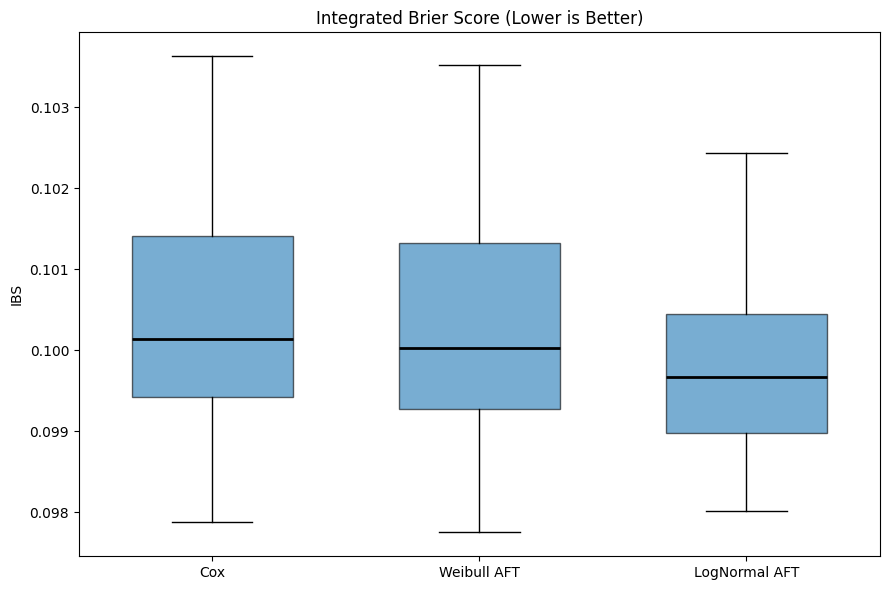

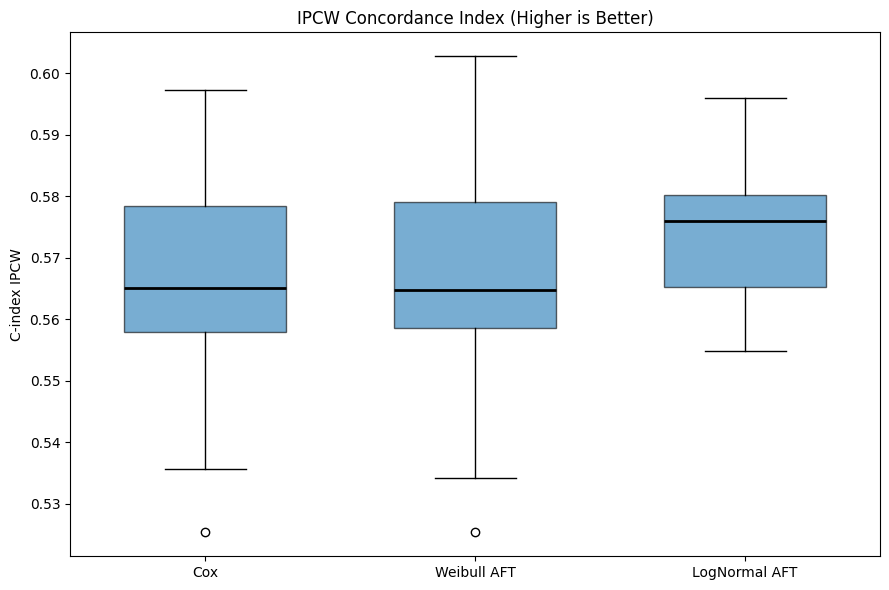


===== Bootstrap Ranking Summary =====
           Model  IBS_mean  IBS_median  Cindex_mean  Cindex_median
2  LogNormal AFT  0.099823    0.099673     0.574288       0.576027
1    Weibull AFT  0.100175    0.100029     0.566507       0.564726
0            Cox  0.100292    0.100135     0.566110       0.565068

Probability of being best (IBS):
{'Cox': np.float64(0.0), 'Weibull AFT': np.float64(0.26), 'LogNormal AFT': np.float64(0.74)}

Probability of being best (C-index IPCW):
{'Cox': np.float64(0.24), 'Weibull AFT': np.float64(0.04), 'LogNormal AFT': np.float64(0.72)}


In [136]:
models = {
    "Cox": CoxPHFitter(penalizer=0.01),
    "Weibull AFT": WeibullAFTFitter(penalizer=0.01),
    "LogNormal AFT": LogNormalAFTFitter(penalizer=0.01),
}

results = survival_bootstrap_model_comparison(
    df_train=df,
    feature_cols=['fin', 'age', 'race', 'wexp'],
    models_dict=models,
    df_val=None,
    duration_col="duration",
    event_col="event",
    start_month_col="start_year_month",
    n_bootstrap=50
)